# CMD Selection

How to select stars from CMD based on given isochrone. This was based on [Datacarpentry tutorial](https://datacarpentry.github.io/astronomy-python/index.html) from Ana Bonaca and Adrian Price-Whelan.

Isochrone generated with [Minimint](https://github.com/segasai/minimint) (Koposov 2023)

In [1]:
# Load CMD data
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

cmd_file = "sample_cmd.fits"

# Load the CMD data from a FITS file
cmd_data = Table.read(cmd_file)

(0.0, 1.0)

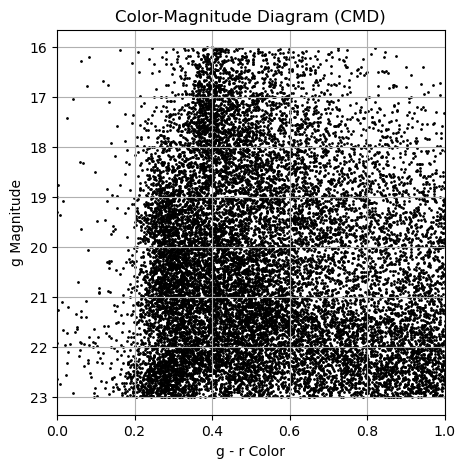

In [2]:
# plot CMD from gmag and grcolor
plt.figure(figsize=(5, 5))
plt.scatter(cmd_data['grcolor'], cmd_data['gmag'], s=1, color='black')
plt.gca().invert_yaxis()
plt.xlabel('g - r Color')
plt.ylabel('g Magnitude')
plt.title('Color-Magnitude Diagram (CMD)')
plt.grid(True)
plt.xlim(0, 1)


## Create Mock Isochrone

Generating isochrone from DECam with certain population, i.e for a mock globular cluster

In [3]:
import minimint

filters = ['DECam_g','DECam_r']
ii = minimint.Interpolator(filters)

massgrid = 10**np.linspace(np.log10(0.1), np.log10(100), 10000)
gc_age = 12  # Gyr
age_log = np.log10(gc_age * 1e9)  # convert to years and take log10

feh = -1.4 
dist = 20 # kpc
modulus = 5 * np.log10(dist * 1000 / 10)  # distance modulus

iso = ii(massgrid, age_log, feh)

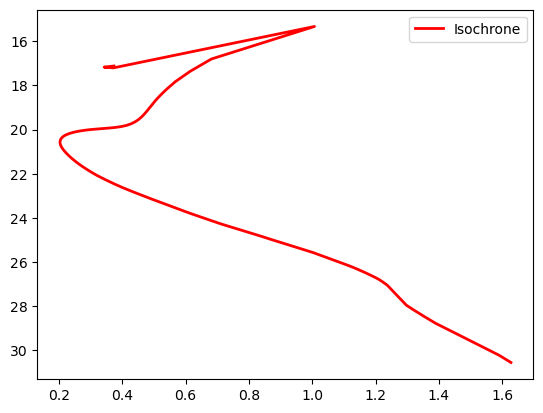

In [4]:
iso["DECam_g_dist"] = iso['DECam_g'] + modulus
iso["Decam_color_gr"] = iso['DECam_g'] - iso['DECam_r']
plt.plot(iso["Decam_color_gr"], iso["DECam_g_dist"], color='red', lw=2, label='Isochrone')
plt.legend()
plt.gca().invert_yaxis()

(23.0, 16.0)

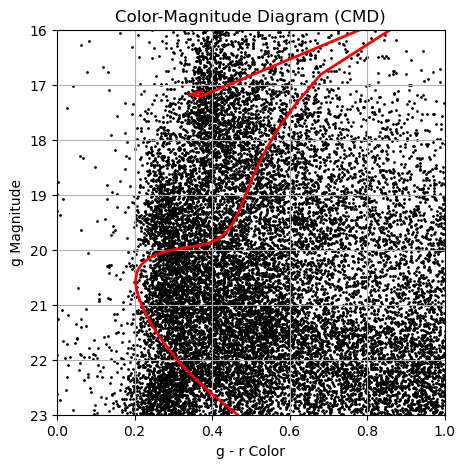

In [5]:
# plot CMD from gmag and grcolor
plt.figure(figsize=(5, 5))
plt.scatter(cmd_data['grcolor'], cmd_data['gmag'], s=1, color='black')
plt.plot(iso["Decam_color_gr"], iso["DECam_g_dist"], color='red', lw=2, label='Isochrone')

plt.gca().invert_yaxis()
plt.xlabel('g - r Color')
plt.ylabel('g Magnitude')
plt.title('Color-Magnitude Diagram (CMD)')
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(23, 16)


In [6]:
import numpy as np
import pandas as pd

# iso is your dict of arrays
# 1) pick the magnitude to cut on
g_all = iso["DECam_g_dist"]          # or iso["DECam_g"] + distmod

# 2) build boolean mask
# The initial boolean mask need to be 1 mag before the plot 
g_mask = (g_all > 15.0) & (g_all < 23.0)
print("Points kept:", g_mask.sum())

# 3) apply mask to every field in the dict
iso_masked = {name: arr[g_mask] for name, arr in iso.items()}

# 4) if you want .head(), convert to a DataFrame
iso_masked_df = pd.DataFrame(iso_masked)
iso_masked_df.head()


Points kept: 377


,logg,logteff,logl,phase,logage,feh,mass,DECam_g,DECam_r,DECam_g_dist,Decam_color_gr
0,4.669818,3.737532,-0.530736,0.0,10.079181,-1.4,0.626008,6.489470,6.024533,22.994620,0.464936
1,4.669321,3.737816,-0.528804,0.0,10.079181,-1.4,0.626440,6.483597,6.019723,22.988747,0.463873
2,4.668822,3.738099,-0.526871,0.0,10.079181,-1.4,0.626873,6.477719,6.014909,22.982869,0.462810
3,4.668323,3.738383,-0.524936,0.0,10.079181,-1.4,0.627306,6.471837,6.010091,22.976987,0.461746
4,4.667823,3.738667,-0.522999,0.0,10.079181,-1.4,0.627740,6.465950,6.005268,22.971100,0.460682


In [7]:
g = iso_masked['DECam_g_dist']
left_color = iso_masked['Decam_color_gr'] - 0.1
right_color = iso_masked['Decam_color_gr'] + 0.1

(23.0, 16.0)

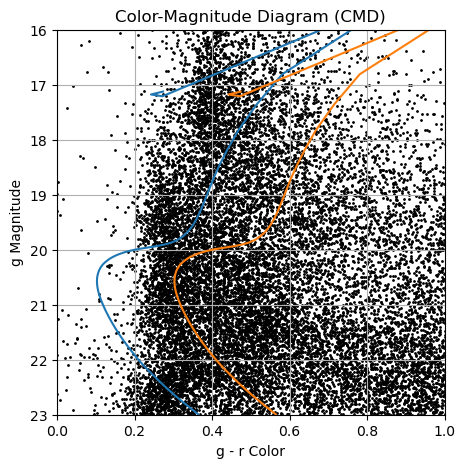

In [8]:
# plot CMD from gmag and grcolor
plt.figure(figsize=(5, 5))
plt.scatter(cmd_data['grcolor'], cmd_data['gmag'], s=1, color='black')
plt.plot(left_color, g, label='left color')
plt.plot(right_color, g, label='right color')

plt.gca().invert_yaxis()
plt.xlabel('g - r Color')
plt.ylabel('g Magnitude')
plt.title('Color-Magnitude Diagram (CMD)')
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(23, 16)


In [9]:
reverse_right_color = right_color[::-1]


In [10]:
import numpy as np
color_loop = np.append(left_color, reverse_right_color)
color_loop.shape


(754,)

In [11]:
mag_loop = np.append(g, g[::-1])
mag_loop.shape


(754,)

(23.0, 16.0)

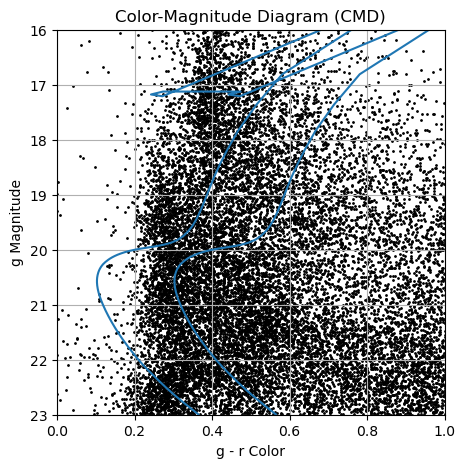

In [12]:

# plot CMD from gmag and grcolor
plt.figure(figsize=(5, 5))
plt.scatter(cmd_data['grcolor'], cmd_data['gmag'], s=1, color='black')
plt.plot(color_loop, mag_loop)
plt.gca().invert_yaxis()
plt.xlabel('g - r Color')
plt.ylabel('g Magnitude')
plt.title('Color-Magnitude Diagram (CMD)')
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(23, 16)




In [13]:
loop_df = pd.DataFrame()
loop_df['color_loop'] = color_loop
loop_df['mag_loop'] = mag_loop
loop_df.head()

,color_loop,mag_loop
0,0.364936,22.994620
1,0.363873,22.988747
2,0.362810,22.982869
3,0.361746,22.976987
4,0.360682,22.971100


In [14]:
from matplotlib.patches import Polygon

polygon = Polygon(loop_df)
polygon

In [15]:
cmd_df = pd.DataFrame()

cmd_df['grcolor'] = cmd_data['grcolor']
cmd_df['gmag'] = cmd_data['gmag']

cmd_df.head()

,grcolor,gmag
0,1.058585,22.406840
1,0.912891,22.162693
2,0.297637,19.151244
3,0.390405,17.934535
4,0.922488,19.288057


## Create closed loop for selection

In [16]:
inside_mask = polygon.contains_points(cmd_df)
inside_mask

array([False, False, False, ...,  True, False, False])

In [17]:
# For astropy 
cmd_df_fixed = cmd_df.copy()

for col in cmd_df_fixed.columns:
    dt = cmd_df_fixed[col].dtype
    # only touch numpy dtypes with explicit big-endian flag
    if hasattr(dt, "byteorder") and dt.byteorder == '>':
        # convert to equivalent little-endian
        cmd_df_fixed[col] = cmd_df_fixed[col].astype(dt.newbyteorder('<'))

selected_df = cmd_df_fixed[inside_mask].copy()


(23.0, 16.0)

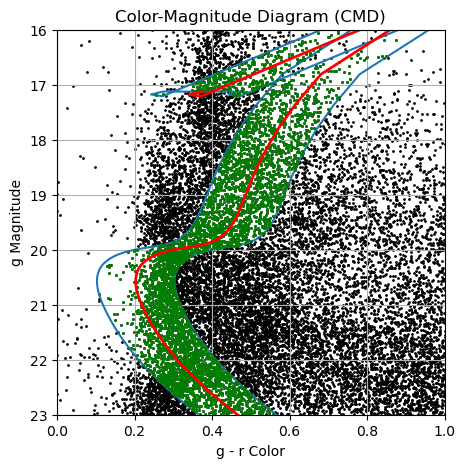

In [18]:
# plot CMD from gmag and grcolor
plt.figure(figsize=(5, 5))
plt.scatter(cmd_data['grcolor'], cmd_data['gmag'], s=1, color='black')
plt.plot(color_loop, mag_loop)

x = selected_df['grcolor']
y = selected_df['gmag']
plt.plot(x, y, 'go', markersize=1, alpha=1)
plt.plot(iso["Decam_color_gr"], iso["DECam_g_dist"], color='red', lw=2, label='Isochrone')


plt.gca().invert_yaxis()
plt.xlabel('g - r Color')
plt.ylabel('g Magnitude')
plt.title('Color-Magnitude Diagram (CMD)')
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(23, 16)

In [19]:
selected_df.head()

,grcolor,gmag
8,0.398899,17.113613
10,0.509454,18.873728
12,0.409533,22.484063
13,0.459391,19.741073
14,0.279140,21.110100
